In [1]:
import numpy as np
import pandas as pd
from phase_space_reconstruction import CCMethod

In [2]:
data_type = ['lorenz','rossler', 'sea_clutter']

In [48]:
def get_data_path(type='lorenz'):
    if type=='lorenz':
        data_path = 'data/original_data/lorenz.csv'
        data = pd.read_csv(data_path)
    elif type=='rossler':
        data_path = 'data/original_data/rossler.csv'
        data = pd.read_csv(data_path)
    elif type=='sea_clutter':
        data_path = 'data/original_data/sea_clutter.xlsx'
        data = pd.read_excel(data_path, header=None)
        data.columns = ['feature_' + str(column) for column in data.columns]
        
    else:
        raise
    return data

In [54]:
def reconstruction(data, m, tau):
    """
    该函数用来重构相空间
    m:嵌入维数
    tau：时间延迟
    return:rec_data-->(m,n)
    """
    n = len(data)
    M = n - (m-1) * tau
    rec_data = np.zeros([m, M])
    # Data = np.zeros([m, M])
    for j in range(M):
        for i in range(m):
            rec_data[i, j] = data[i*tau+j]
    return rec_data

In [74]:
def multi_reconstruction(data_type='lorenz', data_range=(3000,7000), save=True):
    data = get_data_path(data_type)
    data = data.iloc[data_range[0]:data_range[1], :]
    # 初始化字典存取对应的特征的重构数据
    rec_dict = {}
    # feature
    if data_type=='lorenz' or data_type=='rossler':
        features = ['x', 'y', 'z']
    else:
        features = ['feature_%s' % i for i in range(data.shape[1])]
    # 读取对应数据的嵌入维度和延迟tau
    data_tau_m = pd.read_excel('data/%s_tau_m.xlsx' % data_type)
    for feature in features:
        # 读取对应的tau,m
        data_feature = data[feature].values
        tau = data_tau_m[data_tau_m['feature'] == feature]['tau'].tolist()[0]
        m = data_tau_m[data_tau_m['feature'] == feature]['m'].tolist()[0]
        rec_data = reconstruction(data_feature, m, tau)
        rec_dict[feature] = rec_data.T
    if save:
        np.save('data/reconstruction_data/%s_rec_dict.npy' % data_type, rec_dict)
    return rec_dict

In [75]:
lorenz_rec_dict = multi_reconstruction(data_type='lorenz', data_range=(3000,7000))

In [76]:
rossler_rec_dict = multi_reconstruction(data_type='rossler', data_range=(3000,7000))

In [77]:
sea_clutter_rec_dict = multi_reconstruction(data_type='sea_clutter', data_range=(3000,7000))

In [82]:
lorenz_rec_dict['x'].shape

(3936, 5)

In [84]:
lorenz_rec_dict['y'].shape

(3952, 5)

In [85]:
lorenz_rec_dict['z'].shape

(3952, 5)

In [88]:
np.load('data/reconstruction_data/%s_rec_dict.npy' % 'lorenz', allow_pickle=True).tolist()

{'x': array([[  9.86686023,   3.74698156,   4.0966087 ,   9.61047845,
          12.54725936],
        [  9.34047335,   3.60668099,   4.28175643,  10.10519632,
          12.11099134],
        [  8.81069053,   3.49236104,   4.48666605,  10.59927645,
          11.61502467],
        ...,
        [-14.25938   ,  -8.856272  ,   1.729328  ,   5.276306  ,
          11.43239   ],
        [-15.03217   ,  -7.735928  ,   1.988927  ,   5.559662  ,
          11.80069   ],
        [-15.72056   ,  -6.662544  ,   2.228844  ,   5.859542  ,
          12.13112   ]]),
 'y': array([[ 4.64963134,  1.86689394,  3.56042893,  7.526528  , 14.53904371],
        [ 4.04514203,  1.92385437,  3.7861012 ,  8.01262223, 15.06058532],
        [ 3.52402384,  2.00177446,  4.02663812,  8.52627188, 15.51312066],
        ...,
        [ 2.528687  ,  4.463519  ,  5.42424   ,  9.948081  , 15.27592   ],
        [ 3.257292  ,  4.432624  ,  5.657978  , 10.47804   , 15.30874   ],
        [ 3.791354  ,  4.416287  ,  5.917493  , 11.02

In [89]:
min(np.inf,400)

400

In [105]:
# 取最小的样本个数,获取标准数据
def get_final_result(type='lorenz', save=True):
    data_rec_dict = np.load('data/reconstruction_data/%s_rec_dict.npy' % type, allow_pickle=True).tolist()
    # 寻找最小的样本量
    min_sample_num = np.inf
    for key, value in data_rec_dict.items():
        sample_num = value.shape[0]
        min_sample_num = min(min_sample_num, sample_num)
    # 根据min_sample_num取出对应的数据
    print(f'all features min sample number:{min_sample_num}')
    for key, value in data_rec_dict.items():
        value = value[:min_sample_num,:]
        data_rec_dict[key] = value
    if save:
        np.save('data/standard_data/%s_rec_dict.npy' % type, data_rec_dict)
    return data_rec_dict

In [106]:
lorenz_rec_dict1 = get_final_result(type='lorenz')

all features min sample number:3936


In [107]:
rossler_rec_dict1 = get_final_result(type='rossler')

all features min sample number:3918


In [108]:
sea_clutter_rec_dict1 = get_final_result(type='sea_clutter')

all features min sample number:3920


# bls

In [109]:
import numpy as np
from sklearn import preprocessing
from numpy import random
import time

In [110]:
lorenz_rec_dict = np.load('data/standard_data/%s_rec_dict.npy' % 'lorenz',allow_pickle=True).tolist()

In [119]:
X = lorenz_rec_dict['x'][:-1,:]
y = lorenz_rec_dict['x'][1:,-1]

In [ ]:
train_x = X[:3000,:]

# 总结

* mapping feature经过稀疏编码化-->未加激活函数，这与论文不一致
* enhance feature只有1组-->加了激活函数

In [206]:
# 稀疏化编码mapping features
def shrinkage(a, b):
    z = np.maximum(a - b, 0) - np.maximum( -a - b, 0)
    return z

def sparse_bls(A,b):
    lam = 0.001
    itrs = 50
    AA = np.dot(A.T,A)   
    m = A.shape[1]
    n = b.shape[1]
    wk = np.zeros([m,n],dtype = 'double')
    ok = np.zeros([m,n],dtype = 'double')
    uk = np.zeros([m,n],dtype = 'double')
    L1 = np.mat(AA + np.eye(m)).I
    L2 = np.dot(np.dot(L1,A.T),b)
    for i in range(itrs):
        tempc = ok - uk
        ck =  L2 + np.dot(L1,tempc)
        ok = shrinkage(ck + uk, lam)
        uk += ck - ok
        wk = ok
    return wk

def pinv(A,reg):
    return np.mat(reg*np.eye(A.shape[1])+A.T.dot(A)).I.dot(A.T)

In [207]:
class BLS:
    def __init__(self,map_fea_num=6, map_num=5, enh_fea_num=41, enh_num=1, c=2**-30):
        self.map_fea_num = map_fea_num
        self.map_num = map_num
        self.enh_fea_num = enh_fea_num
        self.enh_num = enh_num
        self.c = c
    
    def generator_mapping_features(self, input_channels):
        self.map_weights = []
        for i in range(self.map_num):
            random.seed(i)
            map_fea_weight = 2*random.randn(input_channels+1,self.map_fea_num)-1 # [5+1,6]
            self.map_weights.append(map_fea_weight)
            
    def generator_enhance_features(self):
        self.enhance_weights = []
        for i in range(self.enh_num):
            random.seed(i)
            enh_fea_weight =2*random.randn(self.map_num*self.map_fea_num+1,self.enh_fea_num)-1; #[5*6+1,41]
            self.enhance_weights.append(enh_fea_weight)
            
    def sparse_autoencoder_weights(self, x): # x-->[3000,5]
        H1 = np.hstack([x, 0.1 * np.ones([x.shape[0],1])]); # [3000,6]
        self.map_features = np.zeros([x.shape[0],self.map_num*self.map_fea_num])
        wf_sparse = list()
        distOfMaxAndMin = np.zeros(self.map_num)
        meanOfEachWindow = np.zeros(self.map_num)
        for i in range(self.map_num):
            map_fea_weight = self.map_weights[i] # [6,6]
            A1 = H1.dot(map_fea_weight)
            scaler1 = preprocessing.MinMaxScaler(feature_range=(-1, 1)).fit(A1)
            A1 = scaler1.transform(A1)
            map_sparse_fea_weight  = sparse_bls(A1,H1).T
            wf_sparse.append(map_sparse_fea_weight)
            
            # 重新得到映射特征
            T1 = H1.dot(map_sparse_fea_weight)
            meanOfEachWindow[i] = T1.mean()
            distOfMaxAndMin[i] = T1.max() - T1.min()
            T1 = (T1 - meanOfEachWindow[i])/distOfMaxAndMin[i]  # 标准化T1-->[3000,6]
            # print(T1.shape)
            self.map_features[:,self.map_fea_num*i:self.map_fea_num*(i+1)] = T1
            
    def concat_mapping_enhance_features(self):
        self.combine_features = self.map_features
        for i in range(self.enh_num):
            enh_weight = self.enhance_weights[i]
            H2 = np.hstack([self.map_features,0.1 * np.ones([self.map_features.shape[0],1])]) #[3000,31]
            T2 = H2.dot(enh_weight) # [3000,41]
            T2 = tansig(T2)
            self.combine_features = np.hstack([self.combine_features,T2]) # [3000,71]
            
    def generate_features(self, x):
        _, input_channels = x.shape
        self.generator_mapping_features(input_channels)
        self.generator_enhance_features()
        self.sparse_autoencoder_weights(x)
        self.concat_mapping_enhance_features()
        print(f'combine features shape:{self.combine_features.shape}')
        return self.combine_features
    
    def fit(self, x, y):
        combine_features = self.generate_features(x) # [3000,71]
        weight_last = pinv(combine_features,self.c).dot(y) # [71,1]
        out = combine_features.dot(weight_last)
        print(f'out shape:{out.shape}')
        return out
 

In [203]:
x = np.random.random((3000,5))
y = np.random.random((3000,1))

In [208]:
bls = BLS(map_fea_num=6, map_num=5, enh_fea_num=41, enh_num=2)

In [209]:
combine_features = bls.generate_features(x)

combine features shape:(3000, 112)


In [210]:
out = bls.fit(x,y)

combine features shape:(3000, 112)
out shape:(3000, 1)


In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import d2l.torch as d2l
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# from utils import get_all_result
d2l.use_svg_display()

In [49]:
def normalize(default='MinMaxScaler'):
    if default == "StandardScaler":
        return StandardScaler()
    return MinMaxScaler(feature_range=(-1, 1))

In [6]:
scaler = scaler(default='MinMaxScaler')

In [23]:
x = np.array([[[1,2,3],[4,5,6],[7,8,9]],[[10,11,12],[13,14,15],[16,17,18]]])

In [24]:
x.shape

(2, 3, 3)

In [17]:
scaler?

Type:        MinMaxScaler
String form: MinMaxScaler(feature_range=(-1, 1))
File:        d:\applications\anaconda\envs\pytorch\lib\site-packages\sklearn\preprocessing\_data.py
Docstring:  
Transform features by scaling each feature to a given range.

This estimator scales and translates each feature individually such
that it is in the given range on the training set, e.g. between
zero and one.

The transformation is given by::

    X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
    X_scaled = X_std * (max - min) + min

where min, max = feature_range.

This transformation is often used as an alternative to zero mean,
unit variance scaling.

Read more in the :ref:`User Guide <preprocessing_scaler>`.

Parameters
----------
feature_range : tuple (min, max), default=(0, 1)
    Desired range of transformed data.

copy : bool, default=True
    Set to False to perform inplace row normalization and avoid a
    copy (if the input is already a numpy array).

clip : bool, default=Fal

In [25]:
# out = scaler.fit_transform(x)
out = scaler.fit_transform(x[0])

In [26]:
out

array([[-1., -1., -1.],
       [ 0.,  0.,  0.],
       [ 1.,  1.,  1.]])

In [ ]:
scaler.data_max_

array([7., 8., 9.])

In [ ]:
scaler.inverse_transform(out)

array([[1., 2., 3.],
       [4., 5., 6.],
       [7., 8., 9.]])

In [46]:
del scalers

In [47]:
del scaler

In [55]:
scalers = []
outs = []
for i in range(x.shape[0]):
    scaler = normalize(default='MinMaxScaler')
    out = scaler.fit_transform(x[i])
    # scaler.fit(x[i])
    # scalers.append(scaler)
    # out = scaler.transform(x[i])
    scalers.append(scaler)
    outs.append(out)

In [51]:
scalers

[MinMaxScaler(feature_range=(-1, 1)), MinMaxScaler(feature_range=(-1, 1))]

In [56]:
outs[0]

array([[-1., -1., -1.],
       [ 0.,  0.,  0.],
       [ 1.,  1.,  1.]])

In [57]:
scalers[0].inverse_transform(outs[0])

array([[1., 2., 3.],
       [4., 5., 6.],
       [7., 8., 9.]])

In [58]:
scalers[1].inverse_transform(outs[1])

array([[10., 11., 12.],
       [13., 14., 15.],
       [16., 17., 18.]])

In [59]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [72]:
x = np.arange(300).reshape(3,100,1)
y = np.random.random((100,1))

In [79]:
train_xs,val_xs,train_ys, val_ys = [],[],[],[]
for i in range(x.shape[0]):
    x_i = x[i]
    y_i = y
    train_x,val_x,train_y, val_y = train_test_split(x_i,y_i,train_size=0.7, 
                                                    shuffle=False,random_state=42)
    train_xs.append(train_x)
    val_xs.append(val_x)
    train_ys.append(train_y)
    val_ys.append(val_y)

In [80]:
train_xs[0]

array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19],
       [20],
       [21],
       [22],
       [23],
       [24],
       [25],
       [26],
       [27],
       [28],
       [29],
       [30],
       [31],
       [32],
       [33],
       [34],
       [35],
       [36],
       [37],
       [38],
       [39],
       [40],
       [41],
       [42],
       [43],
       [44],
       [45],
       [46],
       [47],
       [48],
       [49],
       [50],
       [51],
       [52],
       [53],
       [54],
       [55],
       [56],
       [57],
       [58],
       [59],
       [60],
       [61],
       [62],
       [63],
       [64],
       [65],
       [66],
       [67],
       [68],
       [69]])

In [85]:
train_y.shape

(70, 1)

In [2]:
x = torch.rand(100,1)

In [7]:
x

tensor([[0.6073],
        [0.0756],
        [0.5658],
        [0.5113],
        [0.8045],
        [0.2386],
        [0.9282],
        [0.2998],
        [0.9818],
        [0.2430],
        [0.4124],
        [0.7533],
        [0.0393],
        [0.8999],
        [0.6850],
        [0.9489],
        [0.6386],
        [0.9513],
        [0.6341],
        [0.2927],
        [0.4949],
        [0.1357],
        [0.3591],
        [0.0846],
        [0.4460],
        [0.3673],
        [0.4023],
        [0.2988],
        [0.5797],
        [0.8694],
        [0.3044],
        [0.0443],
        [0.6795],
        [0.2550],
        [0.5357],
        [0.8278],
        [0.9117],
        [0.7056],
        [0.1606],
        [0.7926],
        [0.1412],
        [0.8752],
        [0.0991],
        [0.7436],
        [0.7323],
        [0.1450],
        [0.0749],
        [0.2787],
        [0.0368],
        [0.0461],
        [0.0567],
        [0.3212],
        [0.0821],
        [0.2344],
        [0.7495],
        [0

In [3]:
y = torch.rand(1,1)

In [6]:
torch.cat((x,y))

tensor([[0.6073],
        [0.0756],
        [0.5658],
        [0.5113],
        [0.8045],
        [0.2386],
        [0.9282],
        [0.2998],
        [0.9818],
        [0.2430],
        [0.4124],
        [0.7533],
        [0.0393],
        [0.8999],
        [0.6850],
        [0.9489],
        [0.6386],
        [0.9513],
        [0.6341],
        [0.2927],
        [0.4949],
        [0.1357],
        [0.3591],
        [0.0846],
        [0.4460],
        [0.3673],
        [0.4023],
        [0.2988],
        [0.5797],
        [0.8694],
        [0.3044],
        [0.0443],
        [0.6795],
        [0.2550],
        [0.5357],
        [0.8278],
        [0.9117],
        [0.7056],
        [0.1606],
        [0.7926],
        [0.1412],
        [0.8752],
        [0.0991],
        [0.7436],
        [0.7323],
        [0.1450],
        [0.0749],
        [0.2787],
        [0.0368],
        [0.0461],
        [0.0567],
        [0.3212],
        [0.0821],
        [0.2344],
        [0.7495],
        [0

In [8]:
y

tensor([[0.5119]])

# plot

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import d2l.torch as d2l
d2l.use_svg_display()

# 以Lorenz为例

In [2]:
def get_data_path(type='lorenz'):
    if type=='lorenz':
        data_path = 'data/original_data/lorenz.csv'
        data = pd.read_csv(data_path)
    elif type=='rossler':
        data_path = 'data/original_data/rossler.csv'
        data = pd.read_csv(data_path)
    elif type=='sea_clutter':
        data_path = 'data/original_data/sea_clutter.xlsx'
        data = pd.read_excel(data_path, header=None)
        data.columns = ['feature_' + str(column) for column in data.columns]
        
    else:
        raise
    return data

In [68]:
data = get_data_path(type='lorenz')
markers = ['D', '^', 'v', 'p', 'o']
colors = ['#f7797d', '#91eae4', '#240b36', '#38ef7d', 
          '#7303c0', '#cabbe9','#fcbad3','#91eae4','#eaafc8','#8f94fb']

In [54]:
def plot(data,feature='x', start=3000, end=7000, marker=markers[0],
         color=colors[0], axis_off=True, type='lorenz', save=False):
    # data = get_data_path(type=type)
    plt.rcParams['font.sans-serif'] = 'Times New Roman'
    data = data.iloc[start:end,:][feature].values
    plt.plot(data, color=color)
    ax = plt.gca()
    ax.spines['bottom'].set_linewidth(1);  ###设置底部坐标轴的粗细
    ax.spines['left'].set_linewidth(1);  ####设置左边坐标轴的粗细
    ax.spines['right'].set_linewidth(1);  ###设置右边坐标轴的粗细
    ax.spines['top'].set_linewidth(1);  ####设置上部坐标轴的粗细
    plt.axis('off')
    if save:
        plt.savefig('fig/%s_%s_%s_%s.png' % (type, feature,start,end), dpi=300)

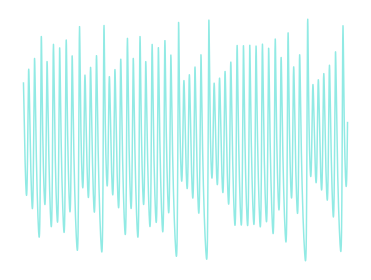

In [72]:
plot(data, feature='z',color=colors[-3], save=True)